In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal , Sequence

In [2]:
class EmployeeState(TypedDict):
    name: str
    salary : float
    age  : int
    decision : Literal ["standard_hr","forced_hr"]
    result : str

In [3]:
def analyse_employee (state: EmployeeState)-> EmployeeState:

    age= state ['age']
    salary= state ['salary']
    if age<=30 and salary <= 4000:
        state['decision']="std_hr"
    else:
        state['decsion']="forced_hr"
        print("le dossier de {state['name']} a été analysé")
    return state

In [4]:
def standard_hr_process(state: EmployeeState):
    state ['result']=f"le dossier de {state['name']} a été traité de manière standard"
    print ("*"*80)
    print(f"le dossier de {state['name']} a été traité de manière standard")
    print("*"*80)
    return state

In [5]:
def forced_hr_process(state: EmployeeState):
    state ['result']=f"le dossier de {state['name']} a été traité de manière forcé"
    print ("="*80)
    print(f"le dossier de {state['name']} a été traité de manière forcé")
    print("="*80)
    return state

In [6]:
def router (state: EmployeeState):
    return state['décision']

In [7]:
workflow =  StateGraph(EmployeeState)
workflow.add_node("analyse_node",analyse_employee)
workflow.add_node("standard_hr_node",standard_hr_process)
workflow.add_node("forced_hr_node",forced_hr_process)
workflow.add_edge(START,"analyse_node")

workflow.add_conditional_edges(
    "analyse_node",
    router,
    {
        "std_hr":"standard_hr_node",
        "forced_hr":"forced_hr_node"
    }

)
workflow.add_edge("standard_hr_node",END)
workflow.add_edge("forced_hr_node",END) 
graph= workflow.compile()

afficher le graphe

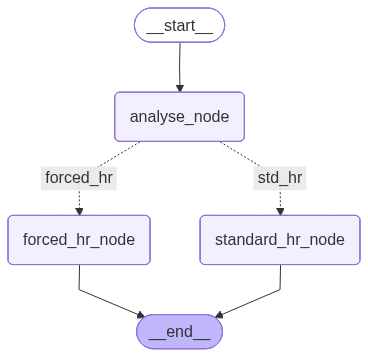

In [8]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

test

In [1]:
result= graph.invoke
({
    "name":"mohamed","age":24,"salary":2000
})
print(result)

NameError: name 'graph' is not defined

créer l'agent

In [ ]:
from langchain.tools import tool
from langchain_core.messages import SystemMessage, AIMessage, ToolMessage, BaseMessage, AnyMessage
from langgraph.graph import add_messages

@tool
def add(a:float,b:float):
    """ Add 2 num a et B"""
    print( f"adding {a} to b")
    return a+b

@tool
def multiply(a:float,b:float):
    """ multiply 2 num a et B"""
    print( f"multiplying {a} by b")
    return a*b

@tool
def dividing(a:float,b:float):
    """ divide 2 num a et B"""
    print( f"dividing {a} by b")
    return a/ b


tools=[add,multiply,dividing]

In [10]:
from typing import TypedDict, Sequence, Annotated
from langchain.tools import tool
from langchain_core.messages import SystemMessage, AIMessage, ToolMessage, BaseMessage, AnyMessage, HumanMessage
from langgraph.graph import add_messages
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from dotenv.ipython import load_dotenv
# Définition d’un état
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [12]:
from dotenv.ipython import load_dotenv
load_dotenv(override=True)
from langchain_openai import ChatOpenAI
llm= ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools=llm.bind_tools(tools=tools)

In [21]:
def assistant(state: AgentState)->AgentState:
    response= llm_with_tools.invoke(state['messages'])
    print("*"*50)
    print("LLM invoke")
    return {"messages":[response]}

In [22]:
def should_continue(state:AgentState):
    last_message = state['messages'][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [26]:
workflow= StateGraph(AgentState)
workflow.add_node("assistant",assistant)
workflow.add_node("tools",ToolNode(tools=tools))
workflow.set_entry_point("assistant")
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "end":END,
        "continue":"tools"
    })
workflow.add_edge("tools","assistant")
graph= workflow.compile()

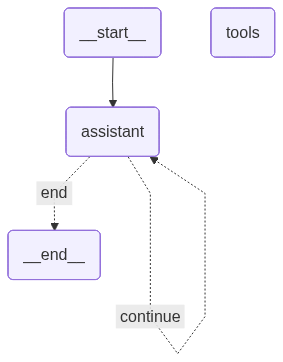

In [24]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":1}}
resp = graph.invoke({
    "messages":[
        HumanMessage("Ajoute 5 à 20 et puis multiplie le résultat par 15 et puis donne moi un proverbe")
    ]
},config=config) 

**************************************************
LLM invoke
adding 5.0 to b
multiplying 25.0 by b
**************************************************
LLM invoke


In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

config={"configurable":{"thread_id":"session test mémoire"}}
resp = graph.invoke({
    "messages":[
        HumanMessage("my name is O ")
    ]
},config=config)
print(resp['messages'][-1].content)



graph.invoke({"messages": [HumanMessage("what's my name?")]}, config=config)

**************************************************
LLM invoke
Hello O! How can I assist you today?
**************************************************
LLM invoke


{'messages': [HumanMessage(content='my name is O ', additional_kwargs={}, response_metadata={}, id='f4272b1a-a05e-4304-9015-60a0a5f2e4fb'),
  AIMessage(content='Hello O! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 103, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a37395bab7', 'id': 'chatcmpl-DZm0XxpIZzbtGKuub6zy39TEaXeg8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd664-4537-7e40-ba6d-461488041963-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 11, 'total_tokens': 114, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

: 